# Projection Accuracy: How Good Were the VORP Projections?
*Justin McKendry*

---

## Purpose

The live draft tool ranks players by `vorp`/`vorp_z` (points above replacement, see
`src/scoring.py`), not raw projected points - so the question that actually matters isn't
"how close was the projected point total" but **how close was the projected *VORP* to the
VORP a player actually delivered?** A player can miss their raw points projection by a lot
and still be exactly as valuable relative to replacement level if everyone around them missed
by a similar amount; VORP is what drives the draft-day recommendation, so it's what should be
graded here.

For every season with both a preseason projection and a real outcome on record (2020-2025),
we compute two VORPs per player using the same replacement-baseline definition
(`src/scoring.py`'s `compute_baselines`/`add_vorp`) the live tool uses everywhere else:

- `proj_vorp` - what the player would have shown on the draft board that year, based on
  their preseason projection and that season's *projected*-points replacement level
- `actual_vorp` - what the player was actually worth once the season played out, based on
  real points and that season's *actual*-points replacement level

The headline question is **how did last season's (2025) VORP projections hold up**, with the
full 2020-2025 history included for context on whether 2025 was a typical year or an outlier.

This is a standalone, informational analysis - it isn't wired into the live scoring or the
public site this round, but it's a direct, honest answer to "how much should I trust the VORP
number next to a player's name on draft day?"

### Setup

In [1]:
import sys
sys.path.insert(0, "..")  # repo root, so `src.*` is importable alongside notebooks/config.py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from config import CURRENT_SEASON, POSITIONS
from utils import load_projection_actuals, add_projection_and_actual_vorp
from IPython.display import display

# --- Configuration for Jupyter ---
%config InlineBackend.figure_formats = ['svg']

In [2]:
engine = create_engine("sqlite:///../data/fantasy_data.db")

## 1. Build the multi-season VORP dataset

One row per player-season with a preseason-projection VORP and an actual-outcome VORP,
computed separately per season since replacement level shifts year to year.
`load_projection_actuals` (`notebooks/utils.py`) pulls straight from `players_stats` rather
than joining through draft/ADP tables, so it covers every season back to 2020 - not just the
2022+ seasons this league has ADP data for. `add_projection_and_actual_vorp` (also in
`notebooks/utils.py`) then applies `src/scoring.py`'s baseline definition twice per season -
once against that year's projected-points distribution, once against its actual-points
distribution - to get `proj_vorp` and `actual_vorp` on the same scale the live draft tool uses.

**Data quality caveat:** the 2023 season has a real extraction gap where `projected_points`
was recorded as `0.0` for nearly every player (e.g. Patrick Mahomes 2023 shows
`points=267.0` but `projected_points=0.0`) - not a legitimate zero projection.
`load_projection_actuals` filters these out (`projected_points != 0`) so they don't
swamp that year's error metrics; other years only lose a handful of isolated zero rows to the
same filter.

In [3]:
YEARS = list(range(2020, CURRENT_SEASON + 1))

def load_year_with_vorp(year):
    df = load_projection_actuals(engine, year)
    df = df[df["position"].isin(POSITIONS)].reset_index(drop=True)
    return add_projection_and_actual_vorp(df)

accuracy_df = pd.concat([load_year_with_vorp(y) for y in YEARS], ignore_index=True)
accuracy_df["vorp_error"] = accuracy_df["proj_vorp"] - accuracy_df["actual_vorp"]

print(f"{len(accuracy_df)} player-seasons across {YEARS}")
accuracy_df.groupby("year").size()

514 player-seasons across [2020, 2021, 2022, 2023, 2024, 2025]


year
2020     95
2021     95
2022     93
2023     14
2024    109
2025    108
dtype: int64

## 2. Overall VORP accuracy by season

RMSE and MAE in VORP points, R² for how much of the variance in actual VORP the projected
VORP explains, and mean signed error (`proj_vorp - actual_vorp`) as a bias check - positive
means projected VORP ran high on average that year, negative means it ran low.

In [4]:
def accuracy_metrics(df):
    return pd.Series({
        "n": len(df),
        "rmse": mean_squared_error(df["actual_vorp"], df["proj_vorp"]) ** 0.5,
        "mae": mean_absolute_error(df["actual_vorp"], df["proj_vorp"]),
        "r2": r2_score(df["actual_vorp"], df["proj_vorp"]),
        "mean_signed_error": df["vorp_error"].mean(),
    })

by_year = accuracy_df.groupby("year").apply(accuracy_metrics, include_groups=False).round(2)
by_year

,n,rmse,mae,r2,mean_signed_error
year,,,,,
2020,95.0,50.87,41.32,0.14,-2.43
2021,95.0,48.43,36.61,0.54,-6.12
2022,93.0,55.66,42.75,0.45,21.68
2023,14.0,38.02,31.40,-0.30,-22.66
2024,109.0,64.58,51.87,0.56,-9.64
2025,108.0,66.49,53.49,0.44,5.75


## 3. VORP accuracy by position

Projection difficulty varies a lot by position - workload-driven positions (RB, and to a
lesser extent WR) are historically harder to project than QB, where the top of the market is
more stable year to year. This aggregates across all seasons for a large-enough sample per
position.

In [5]:
by_position = accuracy_df.groupby("position").apply(accuracy_metrics, include_groups=False).round(2)
by_position = by_position.sort_values("rmse", ascending=False)
by_position

,n,rmse,mae,r2,mean_signed_error
position,,,,,
QB,64.0,69.21,54.91,0.46,-11.76
RB,125.0,65.90,54.32,0.42,2.25
WR,129.0,62.09,49.46,0.05,14.48
TE,65.0,51.15,39.79,-0.09,9.38
DST,64.0,38.71,31.04,-0.44,-15.26
K,67.0,37.90,29.75,-1.75,-8.54


In [6]:
styled = by_position.reset_index().style.hide(axis="index").set_caption(
    "VORP Projection Accuracy by Position (all seasons, 2020-2025)"
)
styled.to_html("../docs/tables/projection_accuracy_by_position.html")
styled

position,n,rmse,mae,r2,mean_signed_error
QB,64.000000,69.210000,54.910000,0.460000,-11.760000
RB,125.000000,65.900000,54.320000,0.420000,2.250000
WR,129.000000,62.090000,49.460000,0.050000,14.480000
TE,65.000000,51.150000,39.790000,-0.090000,9.380000
DST,64.000000,38.710000,31.040000,-0.440000,-15.260000
K,67.000000,37.900000,29.750000,-1.750000,-8.540000


## 4. Projected vs. actual VORP, last season (2025)

A direct scatter of projected VORP vs. actual VORP for the most recently completed season
(`CURRENT_SEASON`). Points on the diagonal reference line would be a perfect VORP projection;
the spread around it is the real-world error the RMSE/MAE numbers above are summarizing. Points
above the line delivered more value than projected (booms); points below delivered less
(busts).

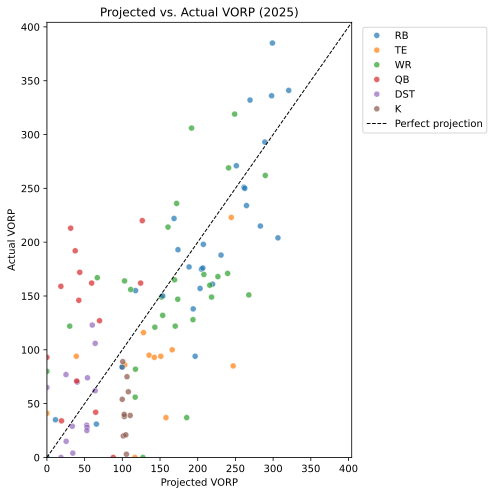

In [7]:
current_df = accuracy_df[accuracy_df["year"] == CURRENT_SEASON]

plt.figure(figsize=(7, 7))
sns.scatterplot(data=current_df, x="proj_vorp", y="actual_vorp", hue="position", alpha=0.7)
lo = min(current_df["proj_vorp"].min(), current_df["actual_vorp"].min()) * 1.05
hi = max(current_df["proj_vorp"].max(), current_df["actual_vorp"].max()) * 1.05
lims = [lo, hi]
plt.plot(lims, lims, "k--", linewidth=1, label="Perfect projection")
plt.axhline(0, color="grey", linewidth=0.5)
plt.axvline(0, color="grey", linewidth=0.5)
plt.xlim(lims)
plt.ylim(lims)
plt.xlabel("Projected VORP")
plt.ylabel("Actual VORP")
plt.title(f"Projected vs. Actual VORP ({CURRENT_SEASON})")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../docs/charts/projection_accuracy_scatter.png")
plt.show()

## 5. Is VORP accuracy improving over time?

RMSE and MAE by season, to see whether ESPN's projections have gotten better, worse, or
stayed flat across the seasons we have data for, and whether 2025 (the headline season above)
is a typical year or an outlier relative to its own history.

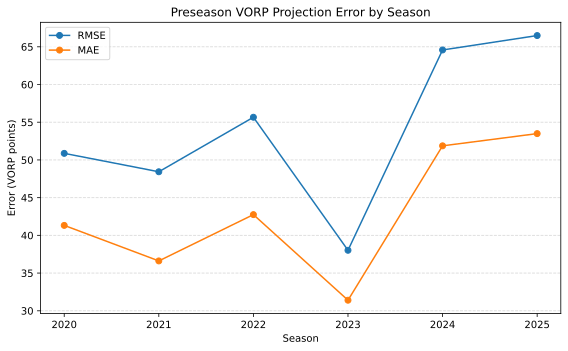

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(by_year.index, by_year["rmse"], marker="o", label="RMSE")
plt.plot(by_year.index, by_year["mae"], marker="o", label="MAE")
plt.xlabel("Season")
plt.ylabel("Error (VORP points)")
plt.title("Preseason VORP Projection Error by Season")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("../docs/charts/projection_accuracy_trend.png")
plt.show()

## 6. Biggest VORP misses (boom/bust), last season (2025)

The players whose *VORP* projections were most wrong in `CURRENT_SEASON` - biggest positive
`vorp_error` (`proj_vorp - actual_vorp`; projected far more value than they delivered -
"busts") and biggest negative `vorp_error` (delivered far more value than projected -
"booms"). Raw projected/actual points are included alongside for context, but the sort and
the headline number are VORP, since that's what would have actually changed a draft-day call.

In [9]:
cols = ["player_name", "position", "pro_team", "projected_points", "actual_points",
        "proj_vorp", "actual_vorp", "vorp_error"]

busts = current_df.sort_values("vorp_error", ascending=False).head(10)[cols].reset_index(drop=True)
booms = current_df.sort_values("vorp_error", ascending=True).head(10)[cols].reset_index(drop=True)

boom_bust = pd.concat(
    [busts.assign(type="bust (overprojected)"), booms.assign(type="boom (underprojected)")],
    ignore_index=True,
)
boom_bust.to_html("../docs/tables/projection_boom_bust.html", index=False)

print("Busts (overprojected VORP):")
display(busts)
print("Booms (underprojected VORP):")
display(booms)

Busts (overprojected VORP):


,player_name,position,pro_team,projected_points,actual_points,proj_vorp,actual_vorp,vorp_error
0,Brock Bowers,TE,LV,261.14,170.0,247.06,85.0,162.06
1,Mike Evans,WR,TB,234.21,83.0,185.39,37.0,148.39
2,Jayden Reed,WR,GB,176.17,46.0,127.35,0.0,127.35
3,Mark Andrews,TE,BAL,171.97,122.0,157.89,37.0,120.89
4,CeeDee Lamb,WR,DAL,316.60,197.0,267.78,151.0,116.78
5,Darren Waller,TE,MIA,130.80,85.0,116.72,0.0,116.72
6,Aaron Jones Sr.,RB,MIN,214.87,111.0,196.57,94.0,102.57
7,Jake Elliott,K,PHI,141.38,109.0,105.44,3.0,102.44
8,Saquon Barkley,RB,PHI,324.71,221.0,306.41,204.0,102.41
9,Joe Burrow,QB,CIN,328.76,129.0,87.96,0.0,87.96


Booms (underprojected VORP):


,player_name,position,pro_team,projected_points,actual_points,proj_vorp,actual_vorp,vorp_error
0,Matthew Stafford,QB,LAR,272.30,342.0,31.50,213.0,-181.50
1,Trevor Lawrence,QB,JAX,278.32,321.0,37.52,192.0,-154.48
2,Jared Goff,QB,DET,259.32,288.0,18.52,159.0,-140.48
3,Dak Prescott,QB,DAL,284.34,301.0,43.54,172.0,-128.46
4,Jaxon Smith-Njigba,WR,SEA,240.65,352.0,191.83,306.0,-114.17
5,Justin Herbert,QB,LAC,283.12,275.0,42.32,146.0,-103.68
6,Bo Nix,QB,DEN,300.11,291.0,59.31,162.0,-102.69
7,Michael Wilson,WR,ARI,115.61,213.0,66.79,167.0,-100.21
8,Josh Allen,QB,BUF,367.28,349.0,126.48,220.0,-93.52
9,Sam Darnold,QB,SEA,240.80,222.0,0.00,93.0,-93.00


## 7. Takeaways

- Preseason *VORP* projections carry real, position-dependent uncertainty - see the RMSE/MAE
  spread in the by-position table above. This is part of the justification for why the live
  draft tool's uncertainty bounds (NB04's bootstrap confidence intervals) matter: a single
  point projection understates how much a player's actual VORP can vary from what was
  projected.
- Position-level accuracy differences are a data point (not yet a code change) for anyone
  extending `src/scoring.py` further - e.g. widening `RECENCY_WEIGHT` or a future confidence
  discount for positions with historically higher VORP projection error.
- Comparing `by_year` to the 2025 row specifically shows whether last year's projections were
  unusually good, unusually bad, or in line with the 2020-2025 baseline - see section 5.
- This notebook is intentionally standalone: it isn't wired into `docs/index.qmd` or the live
  API this round, so re-running it doesn't affect the published site or the draft tool.